# 1. Collaborative Filter  Model_Using

In [2]:
from models.collaborative_filter import CollaborativeFilteringMF
import pandas as pd
import numpy as np
import torch

cf = CollaborativeFilteringMF(
    train_path="data/processed_data/train_processed_data_mf.csv",
    test_path="data/processed_data/test_processed_data_mf.csv",
)

cf.load_model("model_ckpts/collaborative_filter/mf_final.pt")

test_df = pd.read_csv("data/processed_data/test_processed_data_mf.csv")
u = test_df["msno"].map(cf.user2idx).to_numpy()
i = test_df["song_id"].map(cf.item2idx).to_numpy()
y = test_df["target"].to_numpy()

pred = cf.predict_pairs(u, i)


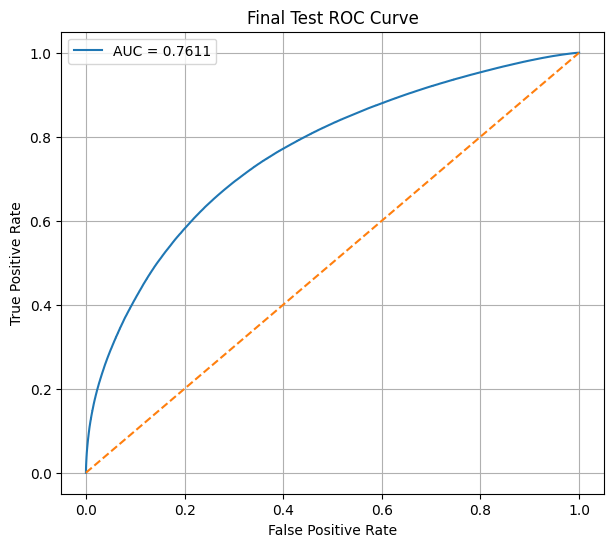

In [3]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y, pred)
final_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 6), dpi = 300)
plt.plot(fpr, tpr, label=f"AUC = {final_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Final Test ROC Curve")
plt.legend()
plt.grid(True)
# plt.savefig("images/models/collaborative_filter/final_auc_curve.png", dpi = 300)
plt.show()

# 2. LightFM Model Using

In [1]:
from models.lgfm import LightFMRecommender
import pandas as pd
import numpy as np
import torch

test_df = pd.read_csv("data/processed_data/test_processed_data.csv")

recommender = LightFMRecommender()
recommender.load_model("model_ckpts/lightfm")

/Users/brench/miniconda3/envs/data_engineering/lib/python3.10/site-packages/lightfm/_lightfm_fast.py:9: UserWarning: LightFM was compiled without OpenMP support. Only a single thread will be used.
  warnings.warn(


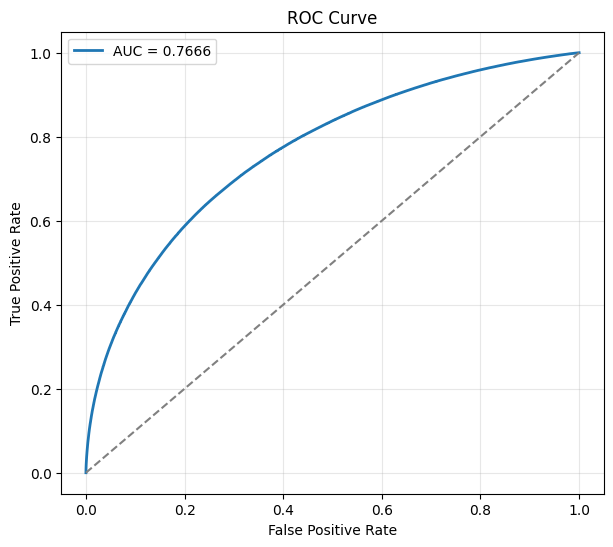

In [2]:
test_user_indices = test_df['msno'].map(recommender.user_id_map).astype(int)
test_song_indices = test_df['song_id'].map(recommender.song_id_map).astype(int)
test_target = test_df['target'].values

final_test_preds = recommender.model.predict(test_user_indices.values, test_song_indices.values)
final_test_prob = 1 / (1 + np.exp(-final_test_preds))

# Plot ROC curve
roc_auc = recommender.plot_roc_curve(test_target, final_test_prob, save_plot=True)

# 3. Lightgbm model using

In [1]:
from models.lgbm import LightGBMTrainer
import pandas as pd
import numpy as np
import logging

logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    handlers=[logging.StreamHandler()]
)

lgbm = LightGBMTrainer()
train_df = pd.read_csv("data/processed_data/train_processed_data.csv")
test_df = pd.read_csv("data/processed_data/test_processed_data.csv")

2025-11-27 03:03:44,069 - INFO - Loading model from model_ckpts/lightgbm_4000rounds_256leaves_lr0dot1/lightgbm_model.pkl
2025-11-27 03:03:44,196 - INFO - Loaded train size: 5897244, test size: 1474312
2025-11-27 03:03:44,196 - INFO - Start evaluation
2025-11-27 03:04:59,796 - INFO - AUC: 0.8053003307896638
2025-11-27 03:05:00,151 - INFO - Precision: 0.7293249801934715, Recall: 0.7367799455486564, F1: 0.7330335090746913
2025-11-27 03:05:00,281 - INFO - Test Log Loss: 0.5384484881351588


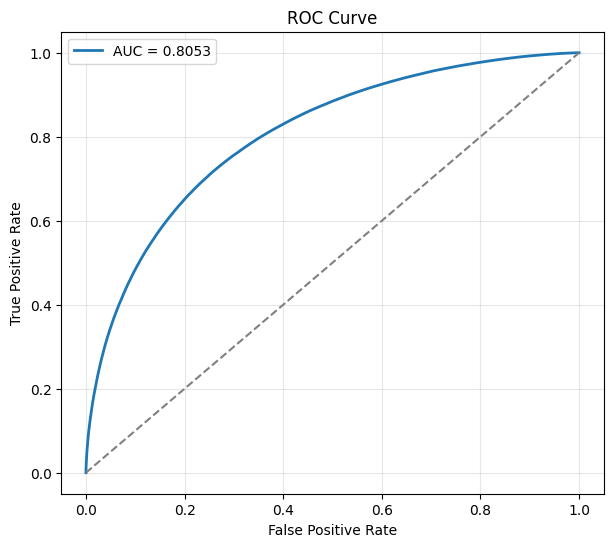

In [2]:
lgbm.load_model("model_ckpts/lightgbm_4000rounds_256leaves_lr0dot1/lightgbm_model.pkl")
lgbm.load_data(train_df, test_df)
lgbm.evaluate(save_plot = False)

# 4. XGBoost Model using

In [1]:
from models.xgb import XGBMusicPredictor
import pandas as pd
import numpy as np
import logging

logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    handlers=[logging.StreamHandler()]
)

xgb = XGBMusicPredictor(
        model_path="model_ckpts/xgboost",  # 模型保存路径
        image_path="images/models/xgboost",
        threshold=0.5  # 确保与训练时相同的阈值
)
train_df = pd.read_csv("data/processed_data/train_processed_data.csv")
test_df = pd.read_csv("data/processed_data/test_processed_data.csv")

In [4]:
xgb.load_model(model_file = "model_ckpts/xgboost/best_model.pkl")
print(xgb.model)

2025-11-27 03:48:32,262 - INFO - Model loaded from model_ckpts/xgboost/best_model.pkl


2025-11-27 03:48:32,866 - INFO - Evaluating model...
2025-11-27 03:48:34,672 - INFO - Final Evaluation - Precision: 0.6500, Recall: 0.6854, F1=0.6672, AUC=0.7129
2025-11-27 03:48:34,676 - WARNING - No training history available. Train the model first.


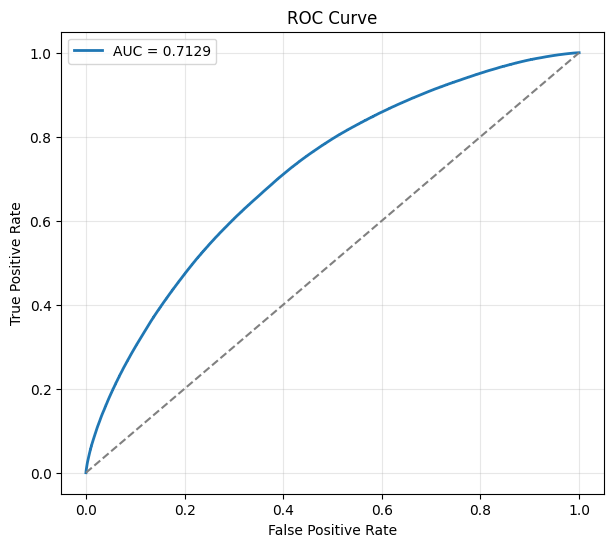

0.7128604404724892

In [5]:
xgb.evaluate(test_df)

xgb.plot_metrics(save_plot = False)
y_pred, y_pred_prob = xgb.predict(test_df)
xgb.plot_roc_curve(test_df["target"].values, y_pred_prob, save_plot = False)